In [1]:
import matplotlib.pyplot as plt
import numpy as np
import csv
from matplotlib.patches import Circle, Rectangle

# %matplotlib inline
# %config InlineBackend.figure_format='retina'

%load_ext autoreload
%autoreload 2

In [2]:
cm = 1/2.54  # centimeters in inches

In [3]:
circ_aa_theory    = np.genfromtxt("./data/circ_aa_theory.txt",    delimiter=",")
circ_ab_theory    = np.genfromtxt("./data/circ_ab_theory.txt",    delimiter=",")
circ_vcz_theory   = np.genfromtxt("./data/circ_vcz_theory.txt",   delimiter=",")
circ_corr_wv_mean = np.genfromtxt("./data/circ_corr_wv_mean.txt", delimiter=",")
circ_r_line = np.genfromtxt("./data/circ_dense_baselines.txt", delimiter=",")
circ_r_dots = np.genfromtxt("./data/circ_baselines.txt", delimiter=",")

rect_aa_theory    = np.genfromtxt("./data/rect_aa_theory.txt",    delimiter=",")
rect_ab_theory    = np.genfromtxt("./data/rect_ab_theory.txt",    delimiter=",")
rect_vcz_theory   = np.genfromtxt("./data/rect_vcz_theory.txt",   delimiter=",")
rect_corr_wv_mean = np.genfromtxt("./data/rect_corr_wv_mean.txt", delimiter=",")
rect_r_line = np.genfromtxt("./data/rect_dense_baselines.txt", delimiter=",")
rect_r_dots = np.genfromtxt("./data/rect_baselines.txt", delimiter=",")

In [4]:
params = {'figure.constrained_layout.use' : True,
          }
plt.rcParams.update(params)

plt.rc('xtick', labelsize='x-small')
plt.rc('ytick', labelsize='x-small')

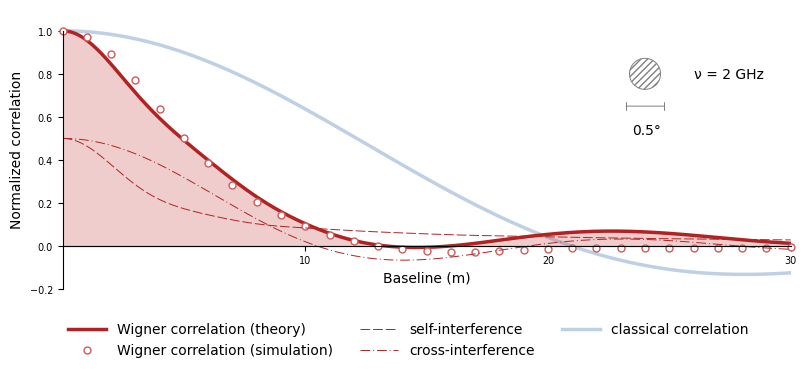

In [28]:
fig, axs = plt.subplots(1, figsize=(21*cm, 10*cm))

res_r_line   = circ_r_line
res_ab       = circ_ab_theory
res_aa       = circ_aa_theory
res_vcz      = circ_vcz_theory
res_dots_sim = circ_r_dots
res_wv_sim   = circ_corr_wv_mean

N = res_ab[0] + res_aa[0]
axs.fill_between(res_r_line, (res_ab + res_aa)/N, ls='-', color='indianred', label=r'', alpha=0.3)
axs.plot(res_r_line, (res_ab + res_aa)/N, ls='-', c='firebrick', lw=2.5, label=r'Wigner correlation (theory)')
axs.plot(res_dots_sim, res_wv_sim, 'o', markersize=5.0, markerfacecolor='white', markeredgewidth=1.0, markeredgecolor='indianred', label='Wigner correlation (simulation)', clip_on=False)


axs.plot(res_r_line, res_aa/N, ls=(0, (10, 3)), c='firebrick', lw=0.7, label=r'self-interference')
axs.plot(res_r_line, res_ab/N, ls=(0, (10, 3, 1, 3)), c='firebrick', lw=0.7, label=r'cross-interference')

axs.plot(res_r_line, res_vcz, c='lightsteelblue', alpha=0.8, lw=2.5, ls='-', label=r'classical correlation', zorder=0)

axs.set_xlabel('Baseline (m)')
axs.set_ylabel('Normalized correlation')
axs.spines[['top', 'right']].set_visible(False)
axs.spines[['bottom']].set_position('zero')

axs.set_xticks([10, 20, 30])
axs.set_xlim(0., 30.)
axs.set_yticks([-0.2, 0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
axs.set_ylim(-0.2, 1.1)
axs.spines['left'].set_bounds(-0.2, 1.0)

axs.scatter(24.0, 0.8, s=500, marker='o', edgecolor='grey', linewidth=0.7, facecolor='none', hatch='/////')
axs.annotate(text='', xy=(23.1, 0.65), xytext=(24.9, 0.65), arrowprops=dict(arrowstyle='|-|, widthA=0.3, widthB=0.3', edgecolor='grey', linewidth=0.7)) ##dict(arrowstyle='|-|', head_length=3, color='grey'))

axs.annotate(u"0.5\u00B0", (23.45, .52))
axs.annotate(u"\u03BD = 2 GHz", (26.0, .78))

# axs.annotate(text='Wigner correlation', xy=(6.0, 0.35), xytext=(8.0, 0.35), arrowprops=dict(arrowstyle='|-|, widthA=0.2, widthB=0.2', edgecolor='grey'))

# dummy items to make the legend look better
# axs.scatter(0, 0, s=0, marker='s', edgecolor='none', linewidth=0, facecolor='none', label=' ')
# axs.scatter(0, 0, s=0, marker='s', edgecolor='none', linewidth=0, facecolor='none', label=' ')
axs.legend(frameon=False, bbox_to_anchor=(0.0, -0.1), loc='upper left', borderaxespad=0., ncols=3, handlelength=2.7)

fig.get_layout_engine().set(w_pad=0.2, h_pad=0.2)

plt.savefig('./figures/front-fig.svg',  dpi=300)
plt.savefig('./figures/front-fig.pdf',  dpi=300, pad_inches=0.5)
plt.show()